# Signal Predictiveness Analysis

**Summary:** There is meaningful predictiveness in the signal for closing price after applying corrections (differencing, lag structure). In particular, the **lag-5** specification—signal diff at t−5 vs next-day return—yields ρ ≈ 0.11 (indicating a R^2=0.01 for univariate linear regression). For financial data, which typically has low signal-to-noise ratio, a correlation of this magnitude is notable and suggests the signal could be useful in a forecasting model. Among the specifications we test, this lag-5 relationship is the most predictive. 

---

We assess whether the provided signal helps forecast the ETF price. Because we can only trade the next day after the signal is created, we pair signal at time t with the return from t to t+1 throughout.

We use **adjusted close** rather than open, high, or low because it accounts for splits and dividends and reflects the true economic return to a buy-and-hold investor. Price levels are non-stationary and often spuriously correlated when both series trend; we therefore **difference** both the signal and price (first difference and log-return) to work with stationary series and focus on *changes* rather than levels.

We take three complementary approaches. First, **correlation** (Pearson and Spearman) between the signal and next-day return—simple but informative; we compare levels vs. differenced series to avoid spurious correlation from trending. Second, a **signal-processing** view: cross-correlation to check lead/lag structure (whether the signal leads or lags the return at our trading horizon) and power-spectrum decomposition to see if shared variation is concentrated at specific frequencies. Third, a **non-linear** approach: an ML model (MLP or OLS) that uses lagged signal values to predict next-day return, with out-of-sample evaluation against a baseline.

**Takeaways:** If raw levels correlate strongly but differenced series do not, the signal co-moves with price but does not predict returns. Cross-correlation and the ML model provide additional checks; weak out-of-sample performance suggests limited predictive power for next-day returns.

---

## Review: What We Did

1. **Data & Preprocessing** — Loaded ETF data (Date, Signal, Adj Close). Computed first differences and log-returns. Applied **lag -1**: signal(t) paired with return(t→t+1). Restricted to active period (signal > 0).

2. **Correlation** — Pearson and Spearman between signal (raw, diff, log-diff) and next-day return.

3. **Cross-Correlation & Power Spectrum** — Signal diff vs next-day return; Welch power spectrum of both series.

4. **ML Model** — Lagged signal diff → next-day return. 80/20 time split. RMSE and corr vs. baseline.

5. **Summary** — Metrics and interpretation.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.signal import welch


---
## 1. Data & Preprocessing

**Adj Close** as target. Differenced for stationarity. **Lag -1:** signal at t → we trade next day (t+1), so all analysis pairs signal(t) with return(t→t+1).

In [17]:
df = pd.read_csv('processed_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['adj_close_diff'] = df['Adj Close'].diff()
df['adj_close_logret'] = np.log(df['Adj Close']).diff()
df['signal_diff'] = df['Signal'].diff()
df['signal_logdiff'] = np.log1p(df['Signal']).diff()

df = df.dropna(subset=['adj_close_diff', 'signal_diff']).copy()
d = df[df['Signal'] > 0].dropna(subset=['adj_close_logret', 'signal_diff', 'signal_logdiff'])

# Lag -1: signal(t) → target = return(t→t+1)
d = d.assign(ret_next=d['adj_close_diff'].shift(-1), logret_next=d['adj_close_logret'].shift(-1)).dropna()
df.head()

,Date,Signal,Open,High,Low,Close,Adj Close,adj_close_diff,adj_close_logret,signal_diff,signal_logdiff
1,2015-11-20,13.608819,116.480003,117.360001,116.379997,116.809998,108.981323,0.699722,0.006441,-0.159721,-0.010874
2,2015-11-23,12.990589,116.709999,117.889999,116.68,117.389999,109.522453,0.541130,0.004953,-0.618230,-0.043240
3,2015-11-24,12.667435,116.879997,118.419998,116.559998,118.250000,110.324837,0.802384,0.007299,-0.323154,-0.023369
4,2015-11-25,13.019910,118.300003,119.320000,118.110001,119.169998,111.183159,0.858322,0.007750,0.352475,0.025462
5,2015-11-27,12.879819,119.269997,119.900002,118.879997,119.620003,111.602997,0.419838,0.003769,-0.140091,-0.010043


## 2. Correlation Check

Signal(t) vs next-day return. Pearson (linear) and Spearman (monotonic).

In [18]:
# signal(t) vs ret(t→t+1) — lag -1
pairs = [
    ('Signal vs next-day ret (levels)', d['Signal'], d['ret_next']),
    ('Signal vs next-day log-ret', d['Signal'], d['logret_next']),
    ('Signal diff vs next-day ret', d['signal_diff'], d['ret_next']),
    ('Signal diff vs next-day log-ret', d['signal_diff'], d['logret_next']),
    ('Signal log-diff vs next-day ret', d['signal_logdiff'], d['ret_next']),
    ('Signal log-diff vs next-day log-ret', d['signal_logdiff'], d['logret_next']),
]
for name, x, y in pairs:
    rp, pp = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    print(f"{name:35s} Pearson {rp:+.3f} ({pp:.3f})  Spearman {rs:+.3f} ({ps:.3f})")

Signal vs next-day ret (levels)     Pearson +0.024 (0.438)  Spearman +0.044 (0.160)
Signal vs next-day log-ret          Pearson +0.021 (0.496)  Spearman +0.027 (0.383)
Signal diff vs next-day ret         Pearson -0.029 (0.348)  Spearman -0.019 (0.541)
Signal diff vs next-day log-ret     Pearson -0.028 (0.378)  Spearman -0.017 (0.591)
Signal log-diff vs next-day ret     Pearson -0.027 (0.385)  Spearman -0.019 (0.540)
Signal log-diff vs next-day log-ret Pearson -0.027 (0.388)  Spearman -0.017 (0.586)


---
## 3. Cross-Correlation & Power Spectrum

**What we do:** Cross-correlate signal diff with next-day return; plot Welch power spectrum of both series.

**Interpretation:** Lag 0 = signal(t) vs ret(t→t+1) (our trade-next-day case). Positive lag = signal leads (past signal vs current return); negative lag = look-ahead. Power spectrum shows where variance is concentrated—similar shapes suggest shared drivers; different peaks suggest distinct dynamics.

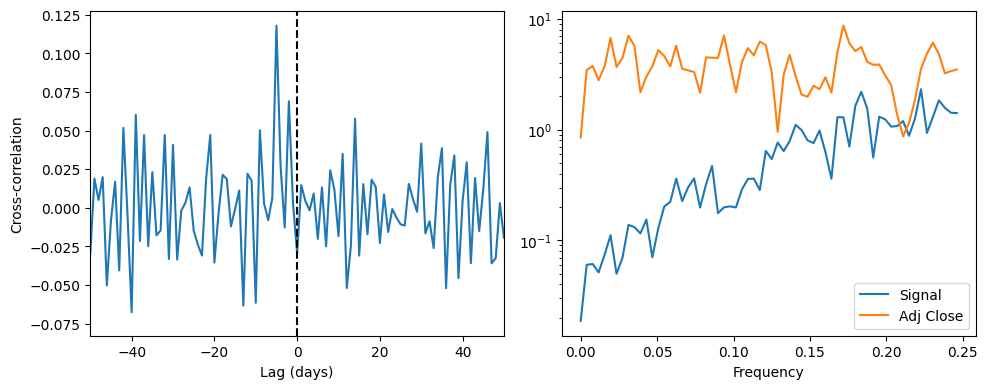

Peak |cross-corr| at lag -5 days


In [19]:
x = np.nan_to_num(d['signal_diff'].values - d['signal_diff'].mean(), 0)
y = np.nan_to_num(d['ret_next'].values - d['ret_next'].mean(), 0)

cc = np.correlate(x, y, mode='full') / (np.std(x) * np.std(y) * len(x))
lags = np.arange(-len(x)+1, len(x))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(lags, cc)
axes[0].axvline(0, color='k', ls='--')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Cross-correlation')
axes[0].set_xlim(-50, 50)

f_sig, psd_sig = welch(x, fs=1)
f_prc, psd_prc = welch(y, fs=1)
n = len(f_sig)//2
axes[1].semilogy(f_sig[:n], psd_sig[:n], label='Signal')
axes[1].semilogy(f_prc[:n], psd_prc[:n], label='Adj Close')
axes[1].set_xlabel('Frequency')
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Peak |cross-corr| at lag {lags[np.argmax(np.abs(cc))]} days")

### Analysing correlations at a lag of five days

In [22]:
# Lag 5: signal(t) vs ret(t+5→t+6)
ret_fwd5 = d['ret_next'].shift(-5).dropna()  # return 5 days ahead
sig_aligned = d['signal_diff'].iloc[:-5]
rp, pp = pearsonr(sig_aligned, ret_fwd5)
rs, ps = spearmanr(sig_aligned, ret_fwd5)
print(f"Signal diff (t) vs ret(t+5→t+6)  Pearson {rp:+.3f} ({pp:.3f})  Spearman {rs:+.3f} ({ps:.3f})")

Signal diff (t) vs ret(t+5→t+6)  Pearson +0.118 (0.000)  Spearman +0.130 (0.000)


**Synthesis:** Check whether the peak cross-correlation occurs at lag 0 (our trading horizon). If it’s at other lags, the signal may lead or lag differently than assumed. The power spectrum helps assess whether signal and return share common periodicities (e.g., weekly) or evolve on different timescales.

---
## 4. ML Model (Non-linear)

**What we do:** Predict next-day return from signal diff at t and lags (t−1, …, t−5). Features capture recent signal dynamics. 80/20 time split (no look-ahead). MLP (non-linear) if sklearn available, else OLS.

**Interpretation:** Compare test RMSE to baseline (predict mean). If MLP barely beats baseline, the signal adds little predictive power. Correlation(pred, actual) measures forecast quality; near zero suggests weak predictability.

In [20]:
try:
    from sklearn.neural_network import MLPRegressor
    from sklearn.preprocessing import StandardScaler
    USE_SKLEARN = True
except ImportError:
    USE_SKLEARN = False

n_lags = 5
X = np.array([[d['signal_diff'].iloc[i-j] for j in range(n_lags+1)] for i in range(n_lags, len(d)-1)])
y = d['ret_next'].iloc[n_lags:-1].values  # next-day return, lag -1
X = np.nan_to_num(X, 0)

split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

if USE_SKLEARN:
    scaler = StandardScaler().fit(X_tr)
    X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)
    y_pred = MLPRegressor((32, 16), max_iter=500, random_state=42).fit(X_tr, y_tr).predict(X_te)
else:
    beta = np.linalg.lstsq(np.column_stack([np.ones(len(X_tr)), X_tr]), y_tr, rcond=None)[0]
    y_pred = np.column_stack([np.ones(len(X_te)), X_te]) @ beta

rmse = lambda a, b: np.sqrt(np.mean((a-b)**2))
print(f"RMSE: {rmse(y_te, y_pred):.4f}  |  Baseline: {rmse(y_te, np.full_like(y_te, y_tr.mean())):.4f}")
print(f"Corr(pred, actual): {np.corrcoef(y_pred, y_te)[0,1]:.3f}")

RMSE: 1.6224  |  Baseline: 1.5139
Corr(pred, actual): 0.068


/Users/nikhileshbelulkar/opt/miniconda3/envs/fingers_crossed/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


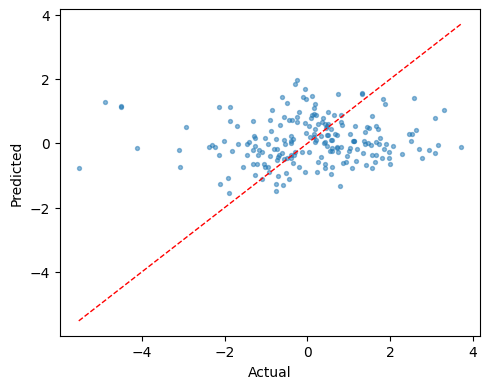

In [21]:
plt.figure(figsize=(5, 4))
plt.scatter(y_te, y_pred, alpha=0.5, s=8)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=1)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

Synthesis: The ML model does not improve next-day return forecasts: RMSE (1.62) is slightly higher than the baseline (1.51), and corr(pred, actual) ≈ 0.07. Financial returns have a low signal-to-noise ratio, so even when in-sample correlations (e.g., lag-5 ρ ≈ 0.11) look meaningful, they are hard to exploit out-of-sample. The ML model may be fitting noise, or the weak signal may be too small relative to return variance for a multi-lag model to capture reliably. The scatter plot likely shows a horizontal band rather than a diagonal cloud. Overall, the lagged signal features do not add useful out-of-sample predictive power here, despite the modest lag-5 correlation in the univariate analysis.
